# Smart Crop Yield Prediction

## About Dataset

The Crop Yield Prediction Dataset is a comprehensive dataset designed to facilitate research and machine learning projects in agriculture and precision farming. This dataset contains a variety of features related to environmental conditions, soil characteristics, crop management practices, and historical crop data to predict crop yield (tons per hectare).

**Dataset Details**
- **Number of Rows**: 10,000 (simulated entries)
- **Number of Columns**: 13
- **Target Variable**: Yield_ton_per_ha – the crop yield in tons per hectare.

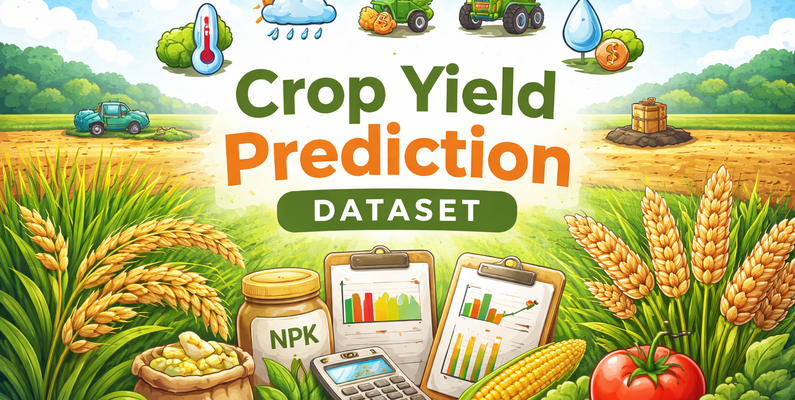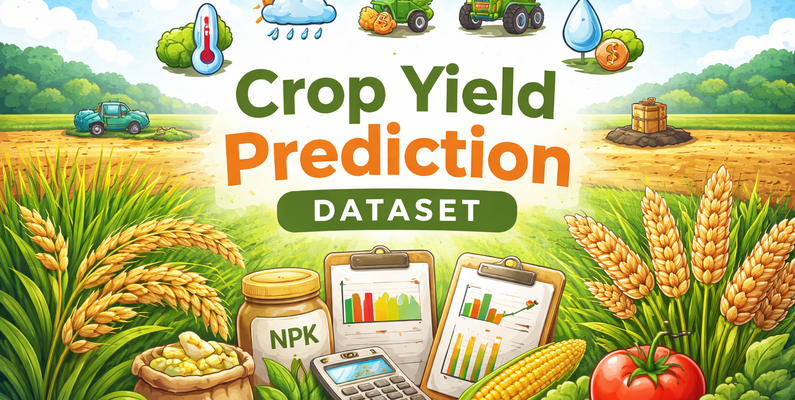

## Packages

In [1]:
# Importing Data Manipulation Packages
import pandas as pd
import numpy as np

# Importing Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Import Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV

# Import Models Being Used
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset

In [2]:
df = pd.read_csv("crop_yield_dataset.csv")
df.head()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,NaN,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


## Data Overview

In [3]:
# Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          7462 non-null   object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       7969 non-null   object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [4]:
# Looking at Null Values
df.isnull().sum()

Crop                     0
Region                   0
Soil_Type                0
Soil_pH                  0
Rainfall_mm              0
Temperature_C            0
Humidity_pct             0
Fertilizer_Used_kg       0
Irrigation            2538
Pesticides_Used_kg       0
Planting_Density         0
Previous_Crop         2031
Yield_ton_per_ha         0
dtype: int64

In [5]:
# Looking at Duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# Unique Values for All Categorical
categorical = df.select_dtypes(include="object").columns.tolist()
for i in categorical:
    print(df[i].unique())
    print("-"*50)

['Maize' 'Barley' 'Rice' 'Wheat']
--------------------------------------------------
['Region_C' 'Region_D' 'Region_B' 'Region_A']
--------------------------------------------------
['Sandy' 'Loam' 'Clay']
--------------------------------------------------
['Drip' 'Sprinkler' nan 'Flood']
--------------------------------------------------
['Rice' 'Barley' 'Wheat' nan 'Maize']
--------------------------------------------------


## EDA

### Univariate Analysis

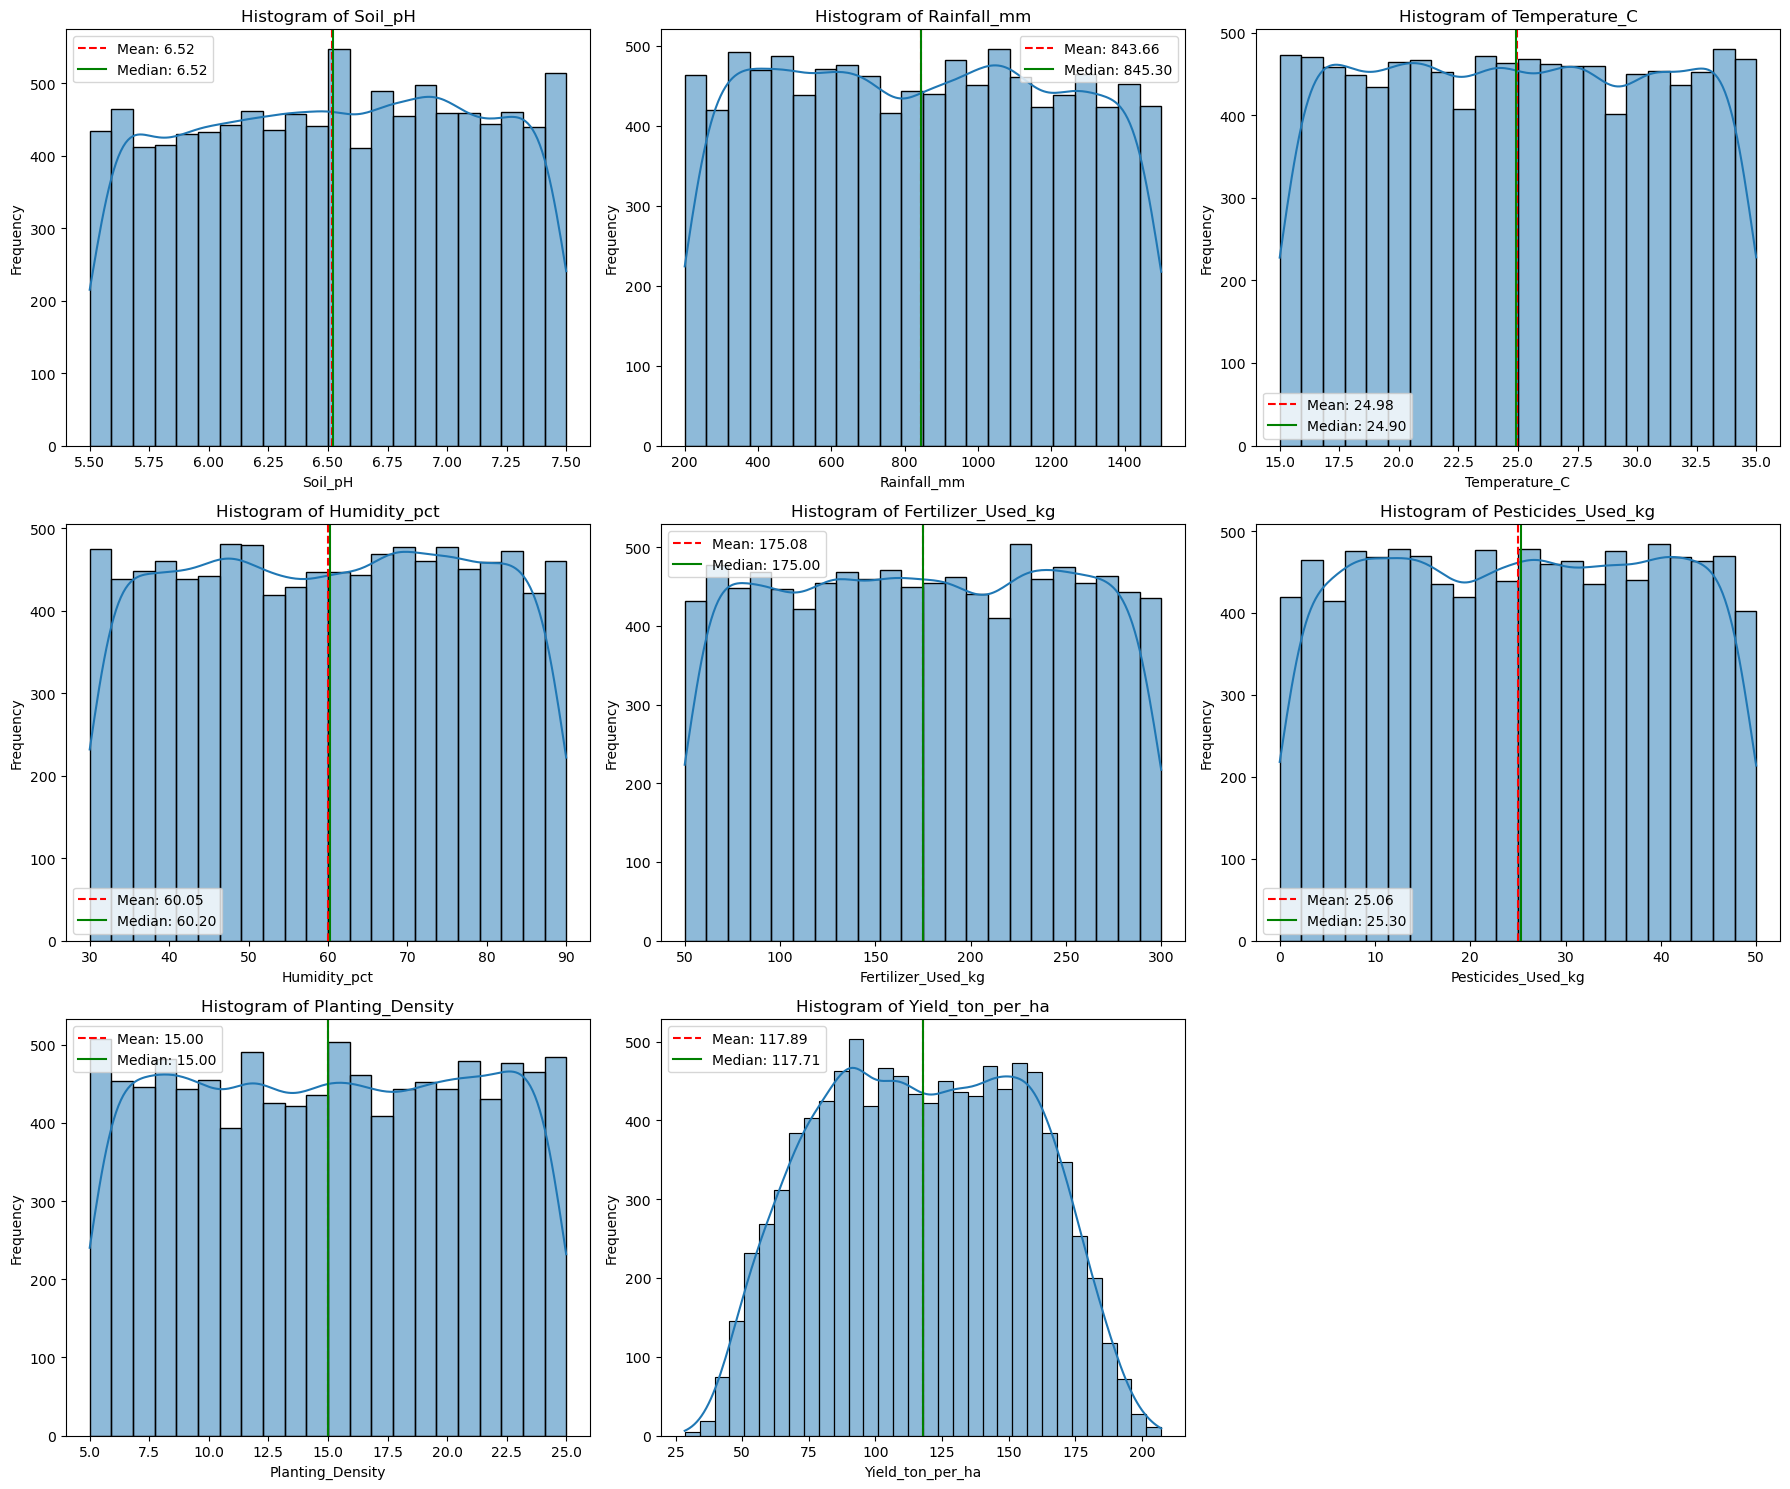

In [7]:
# Histograms
numerical = df.select_dtypes(include=np.number).columns.tolist()
n_cols = 3
n_rows = math.ceil(len(numerical) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))  # one figure for all subplots

for idx, i in enumerate(numerical, start=1):
    mean_value = df[i].mean()
    median_value = df[i].median()

    # Subplot placement
    plt.subplot(n_rows, n_cols, idx)

    sns.histplot(df[i], kde=True)

    # Add vertical lines for mean and median
    plt.axvline(mean_value, color='r', linestyle='--', label=f'Mean: {mean_value:.2f}')
    plt.axvline(median_value, color='g', linestyle='-', label=f'Median: {median_value:.2f}')

    plt.title(f'Histogram of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

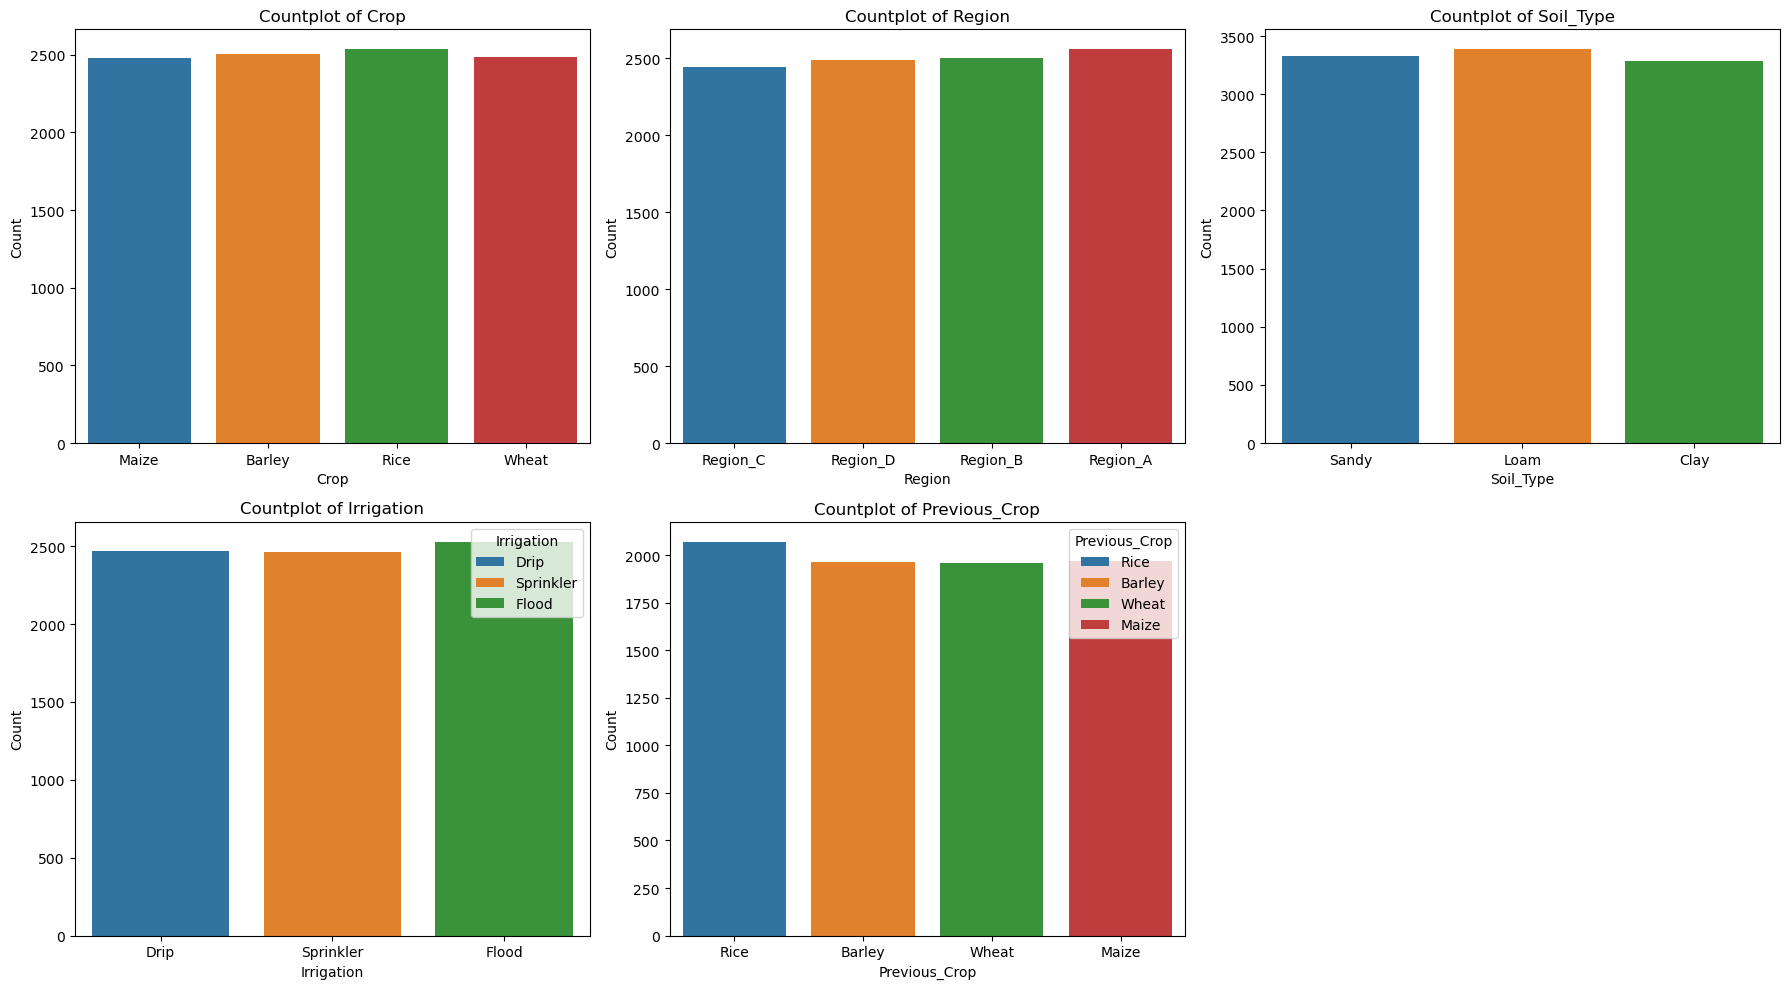

In [8]:
# Categorical
n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for idx, i in enumerate(categorical, start=1):
    plt.subplot(n_rows, n_cols, idx)

    sns.countplot(x=df[i],hue=df[i])

    plt.title(f'Countplot of {i}')
    plt.xlabel(i)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Bivariate Analysis

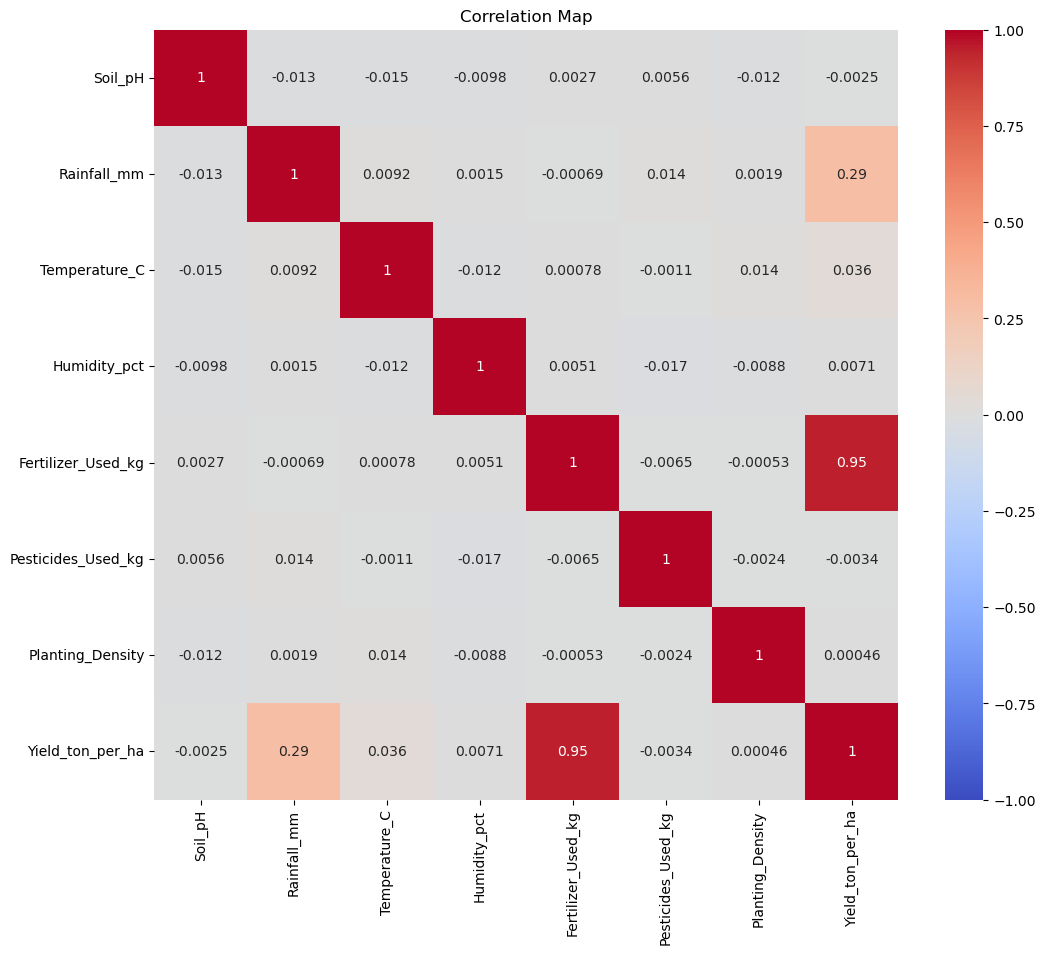

In [9]:
# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df[numerical].corr(),annot=True,vmin=-1,vmax=1,cmap='coolwarm')
plt.title("Correlation Map")
plt.show()

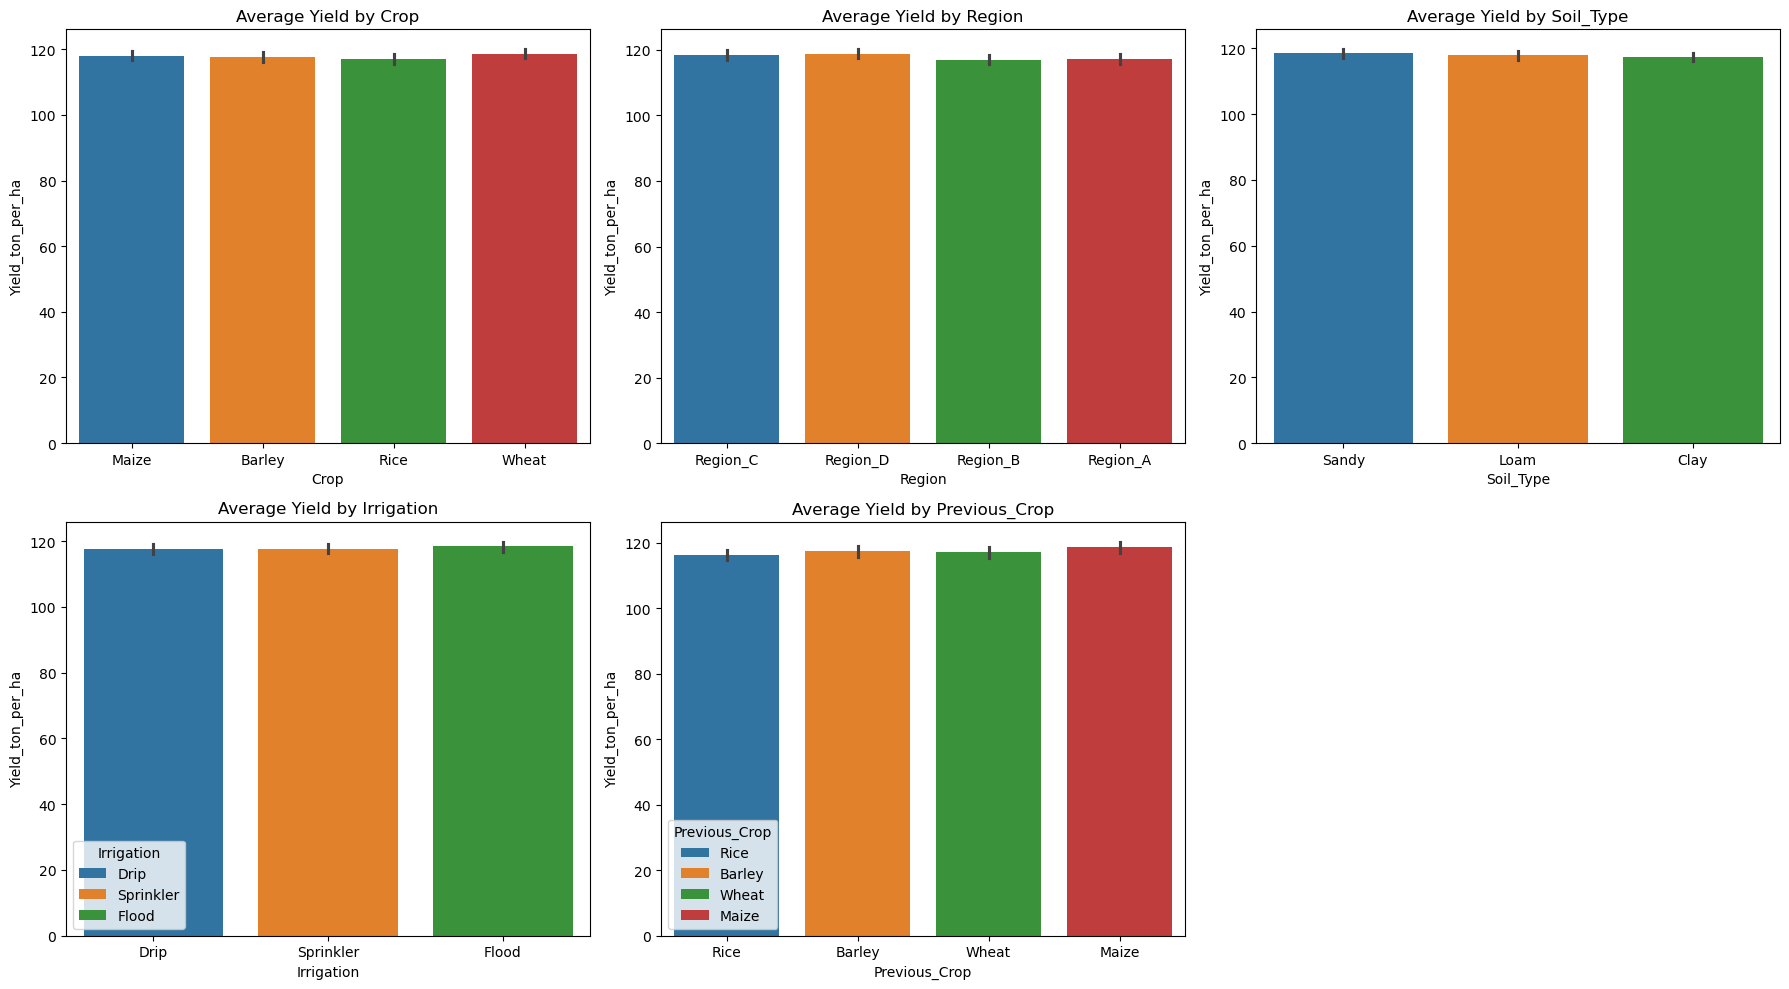

In [10]:
# Looking at each Categorical Variable Yield per Ton
n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for idx, i in enumerate(categorical, start=1):
    plt.subplot(n_rows, n_cols, idx)

    sns.barplot(data=df, x=i, y="Yield_ton_per_ha", hue=i)

    plt.title(f'Average Yield by {i}')
    plt.xlabel(i)
    plt.ylabel("Yield_ton_per_ha")

plt.tight_layout()
plt.show()

## Model Creation

### Data Preprocessing

In [11]:
# Accounting for Null Values
df['Irrigation'] = df['Irrigation'].fillna('Unknown')
df['Previous_Crop'] = df['Previous_Crop'].fillna('Unknown')

df.isnull().sum()

Crop                  0
Region                0
Soil_Type             0
Soil_pH               0
Rainfall_mm           0
Temperature_C         0
Humidity_pct          0
Fertilizer_Used_kg    0
Irrigation            0
Pesticides_Used_kg    0
Planting_Density      0
Previous_Crop         0
Yield_ton_per_ha      0
dtype: int64

In [12]:
# Creating X and Y Variable
X = df.drop("Yield_ton_per_ha",axis=1)
y = df["Yield_ton_per_ha"]

# Creating Dummy Variables
X = pd.get_dummies(X,drop_first=True,dtype=int)

# Creating Training and Test Set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Looking at shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 22)
(2000, 22)
(8000,)
(2000,)


### Model Building

In [13]:
def evaluation(model, predictors, target):
    y_pred = model.predict(predictors)
    mse = mean_squared_error(target, y_pred)
    r2 = r2_score(target, y_pred)
    adj_r2 = 1 - (1 - r2) * ((predictors.shape[0] - 1) / (predictors.shape[0] - predictors.shape[1] - 1))
    mape = np.mean(np.abs((target - y_pred) / target)) * 100
    return mape, mse, r2, adj_r2

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Train metrics
    train_mape, train_mse, train_r2, train_adj_r2 = evaluation(model, X_train, y_train)

    # Test metrics
    test_mape, test_mse, test_r2, test_adj_r2 = evaluation(model, X_test, y_test)

    results.append({
        "Model": name,
        "Train MAPE": train_mape,
        "Test MAPE": test_mape,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train Adjusted R²": train_adj_r2,
        "Test Adjusted R²": test_adj_r2
    })

baseline_results = pd.DataFrame(results)
baseline_results

,Model,Train MAPE,Test MAPE,Train MSE,Test MSE,Train R²,Test R²,Train Adjusted R²,Test Adjusted R²
0,Linear Regression,3.830597,3.990770,25.021363,25.812527,0.982634,0.982124,0.982586,0.981925
1,Random Forest,1.515459,4.219708,3.972074,29.173031,0.997243,0.979797,0.997236,0.979572
2,Gradient Boosting,3.647156,4.094857,22.725522,27.047712,0.984227,0.981269,0.984183,0.981060


### Residuals vs Predicted for Baseline

In [15]:
def plot_diagnostics(model, X_test, y_test):
    # Predictions
    test_pred = model.predict(X_test)

    # Residuals
    test_residuals = y_test - test_pred

    plt.figure(figsize=(18, 5))

    # --- 1. Residuals vs Predicted ---
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=test_pred, y=test_residuals, alpha=0.5, label="Test")
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuals vs Predicted")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.legend()

    # --- 2. Residual Distribution ---
    plt.subplot(1, 3, 2)
    sns.histplot(test_residuals, kde=True, color='orange', alpha=0.5, label="Test")
    plt.title("Residual Distribution")
    plt.xlabel("Residual")
    plt.legend()

    # --- 3. Predicted vs Actual (Test Only) ---
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=y_test, y=test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linestyle='--')  # perfect prediction line
    plt.title("Predicted vs Actual (Test)")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")

    plt.tight_layout()
    plt.show()

Linear Regression


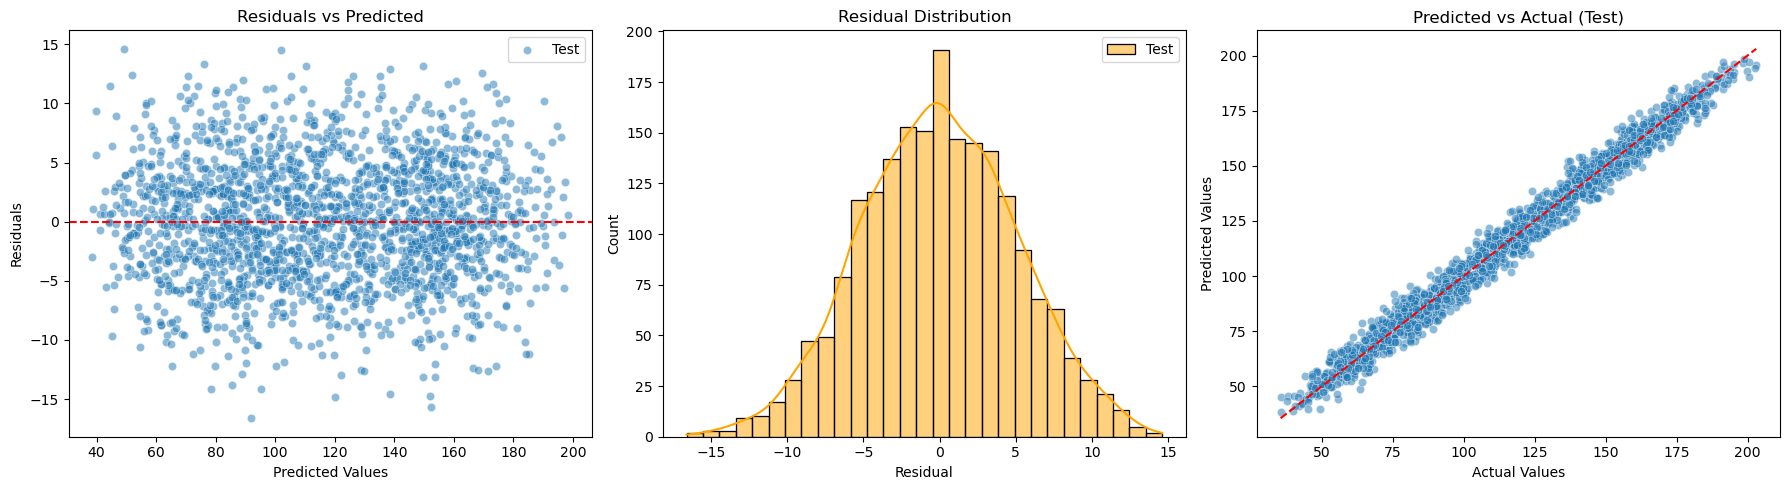

Random Forest


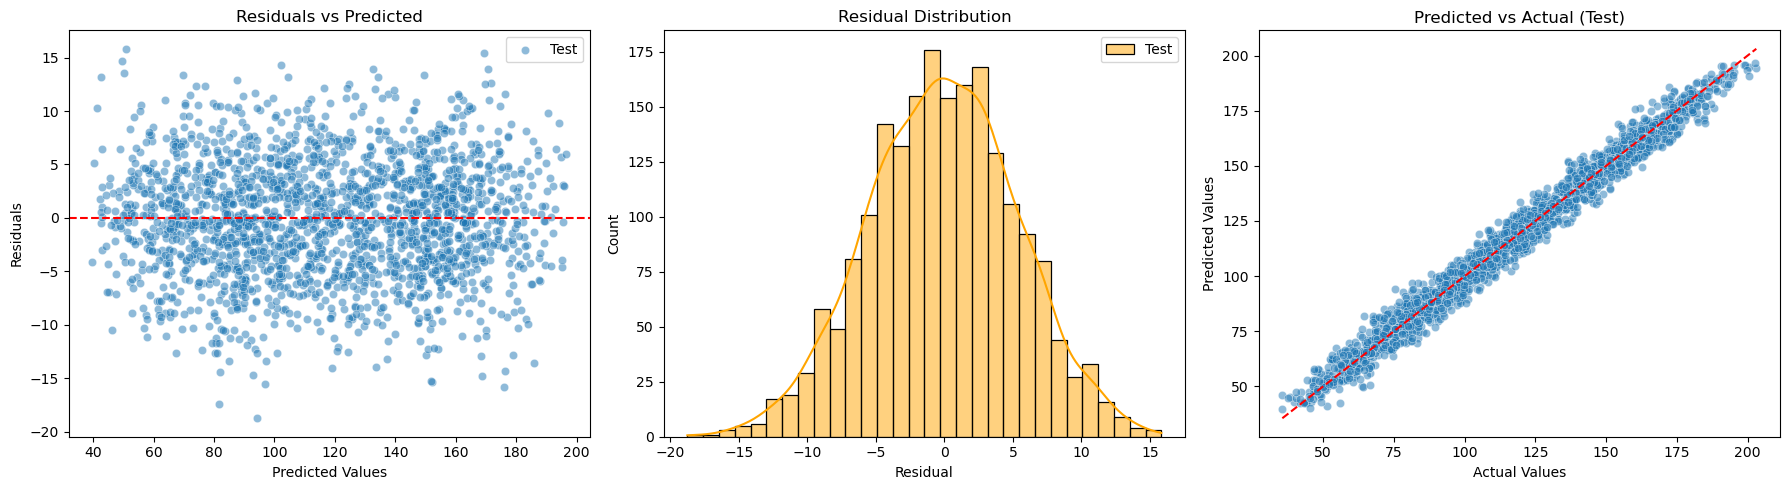

Gradient Boosting


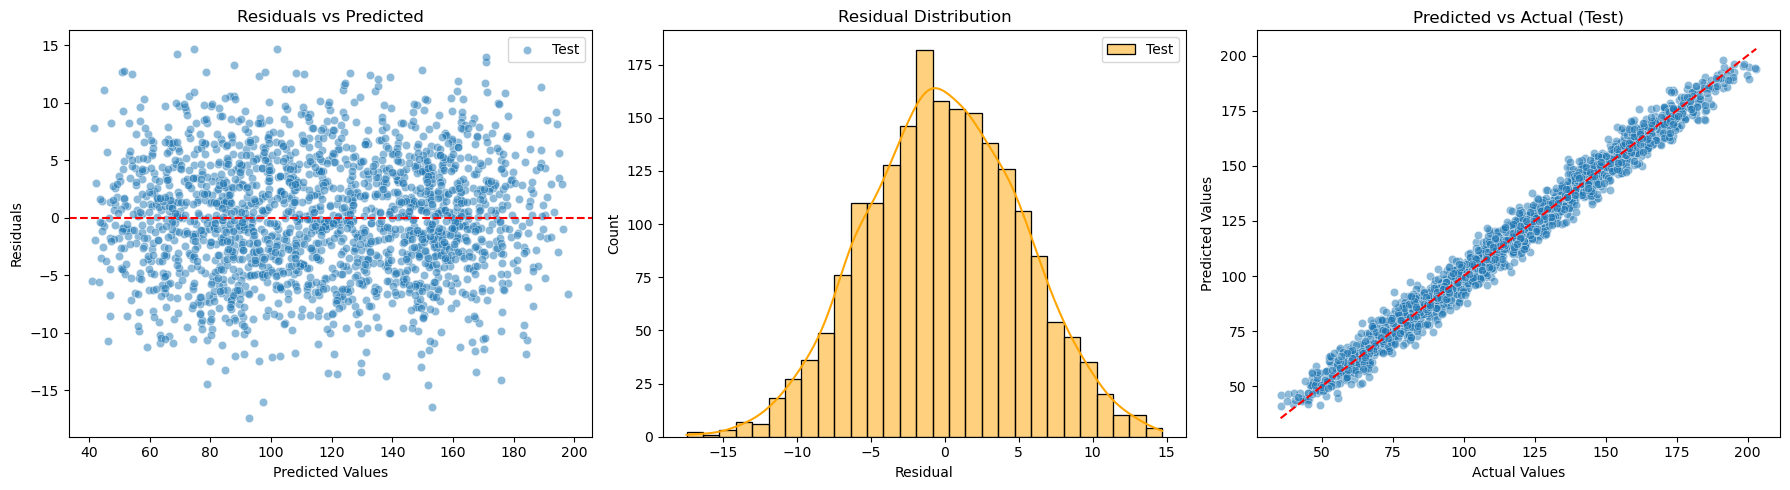

In [16]:
for name, model in models.items():
    print(name)
    plot_diagnostics(model, X_test, y_test)

### Gradient Boosting Tuned vs Tuned Random Forest vs Linear Regression

In [18]:
# Random Forest Tuned
rf_tuned = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# Gradient Voosting Tuned
gb_tuned = GradientBoostingRegressor(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=3,
    subsample=0.8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# --- Models dictionary including tuned versions ---
models_tuned = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest (Tuned)": rf_tuned,
    "Gradient Boosting (Tuned)": gb_tuned
}

# --- Evaluation loop ---
results = []

for name, model in models_tuned.items():
    model.fit(X_train, y_train)

    # Train metrics
    train_mape, train_mse, train_r2, train_adj_r2 = evaluation(model, X_train, y_train)

    # Test metrics
    test_mape, test_mse, test_r2, test_adj_r2 = evaluation(model, X_test, y_test)

    results.append({
        "Model": name,
        "Train MAPE": train_mape,
        "Test MAPE": test_mape,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train Adjusted R²": train_adj_r2,
        "Test Adjusted R²": test_adj_r2
    })

tuned_results = pd.DataFrame(results)
tuned_results

,Model,Train MAPE,Test MAPE,Train MSE,Test MSE,Train R²,Test R²,Train Adjusted R²,Test Adjusted R²
0,Linear Regression (Baseline),3.830597,3.990770,25.021363,25.812527,0.982634,0.982124,0.982586,0.981925
1,Random Forest (Tuned),4.838898,7.735757,35.330834,87.435547,0.975478,0.939449,0.975410,0.938775
2,Gradient Boosting (Tuned),3.509005,4.128329,21.088416,27.193769,0.985363,0.981168,0.985323,0.980958


### Looking at the Feature Importance

In [22]:
# After fitting your model:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Get coefficients
coefficients = lin_model.coef_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by="Absolute Importance", ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Importance
4,Fertilizer_Used_kg,0.499016,0.499016
2,Temperature_C,0.218385,0.218385
21,Previous_Crop_Wheat,-0.162984,0.162984
18,Previous_Crop_Maize,-0.119945,0.119945
11,Region_Region_C,0.100447,0.100447
16,Irrigation_Sprinkler,-0.090687,0.090687
13,Soil_Type_Loam,-0.073001,0.073001
9,Crop_Wheat,-0.066923,0.066923
12,Region_Region_D,0.057366,0.057366
17,Irrigation_Unknown,-0.051916,0.051916
